In [51]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.signal import peak_widths
import pandas as pd
import wfdb
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import warnings
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [ ]:
base_path = "D:/ML/projects/ECG"
processed_data  = f"{base_path}/processed_data"
features_folder = f"{base_path}/features"
data_folder = f"{base_path}/data"

In [ ]:
def extract_features(patient_id, clean_signal, peaks):
    rr_intervals_seconds = np.diff(peaks) / 360.0
    heart_rates = 60.0 / rr_intervals_seconds
    widths_samples, _, _, _ = peak_widths(clean_signal, peaks, rel_height=0.5)
    qrs_widths_ms = (widths_samples / 360.0) * 1000
    peak_amplitudes = clean_signal[peaks]

    return pd.DataFrame({
        'Patient_ID'  : patient_id,
        'Beat_ID'     : np.arange(1, len(rr_intervals_seconds) + 1),
        'RR_Interval' : rr_intervals_seconds,
        'Heart_Rate'  : heart_rates,
        'QRS_Width'   : qrs_widths_ms[1:],
        'R_Amplitude' : peak_amplitudes[1:],
    })


In [ ]:
"""SKITP - DATA ALREADY PROCESSED , Final_ECG_Dataset.csv exist locally"""

# all_files = os.listdir(processed_data)
# clean_files = sorted([f for f in all_files if f.endswith('_clean.npy')])

# for filename in clean_files:
#     patient_id   = filename.split('_')[0]
#     clean_signal = np.load(f"{processed_data}/{filename}")
#     # detecting peak
#     peaks, _ = find_peaks(clean_signal, distance=100, height=np.max(clean_signal)*0.5)
#     #timing features
#     rr_intervals_seconds = np.diff(peaks) / 360.0
#     heart_rates          = 60.0 / rr_intervals_seconds
#     # morphology Features
#     widths_samples, _, _, _ = peak_widths(clean_signal, peaks, rel_height=0.5)
#     qrs_widths_ms = (widths_samples / 360.0) * 1000
#     peak_amplitudes = clean_signal[peaks]
#     df = pd.DataFrame({
#         'Patient_ID' : patient_id,
#         'Beat_ID'    : np.arange(1, len(peaks)),
#         'R_Peak_Loc' : peaks[1:],
#         'RR_Interval': rr_intervals_seconds,
#         'Heart_Rate' : heart_rates,
#         'QRS_Width'  : qrs_widths_ms[1:],
#         'R_Amplitude': peak_amplitudes[1:],
#         'Label'      : 'N'
#     })

#     df.to_csv(f"{features_folder}/{patient_id}_features.csv", index=False)

In [ ]:
# TOLERANCE    = 36 #0.1 seconds at 360 hz
# feature_files = [f for f in os.listdir(features_folder) if f.endswith('_features.csv')]

# for filename in feature_files:
#     csv_path   = f"{features_folder}/{filename}"
#     df = pd.read_csv(csv_path)
#     patient_id = filename.split('_')[0]

#     annotation  = wfdb.rdann(f"{data_folder}/{patient_id}", 'atr')
#     ann_samples = annotation.sample
#     ann_symbols = annotation.symbol

#     new_labels = []
#     for my_peak in df['R_Peak_Loc']:
#         diffs = np.abs(ann_samples - my_peak)
#         closest_idx = np.argmin(diffs)
#         if diffs[closest_idx] <= TOLERANCE:
#             new_labels.append(ann_symbols[closest_idx])
#         else:
#             new_labels.append('X')

#     df['Label'] = new_labels
#     df  = df[df['Label'] != 'X']
#     df.to_csv(csv_path, index=False)

In [ ]:
# """N       Normal    N, L, R, e, j
# S  Supraventricular  A, a, J, S
# V  Ventricular       V, E
# F  Fusion            F
# Q  Unknown/Paced     /, f, u"""
# aami_map = {
#     'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
#     'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
#     'V': 'V', 'E': 'V',
#     'F': 'F',
#     '/': 'Q', 'f': 'Q', 'u': 'Q'
# }
# all_files = [f for f in os.listdir(features_folder) if f.endswith('_features.csv')]
# all_dataframes = []
# for filename in all_files:
#     df = pd.read_csv(f"{features_folder}/{filename}")
#     df = df[df['Label'].isin(aami_map.keys())].copy()
#     df['Label'] = df['Label'].map(aami_map)
#     all_dataframes.append(df)

# final_df = pd.concat(all_dataframes, ignore_index=True)
# final_df.to_csv(f"{base_path}/Final_ECG_Dataset.csv", index=False)

In [ ]:
class GeneticAlgorithmFeatureSelection:
    def __init__(self, X, y, pop_size=20, n_generations=15, mutation_rate=0.1):
        self.X = X #input variables
        self.y = y#target variable
        self.pop_size = pop_size #number of chromosome in population
        self.n_generations = n_generations #iterations
        self.mutation_rate = mutation_rate #Pm i.e mutation probability
        self.n_features = X.shape[1]
        self.classifier = DecisionTreeClassifier(random_state=42)

    def _initialize_population(self):
        return np.random.randint(2, size=(self.pop_size, self.n_features)).astype(int)

    def _calculate_fitness(self, chromosome):
        selected = np.where(chromosome == 1)[0].astype(int)
        if len(selected) == 0:
            return 0.0
        scores = cross_val_score(self.classifier, self.X[:, selected], self.y, cv=3, scoring='accuracy')
        return scores.mean()

    def _crossover(self, parent1, parent2):
        point  = np.random.randint(1, self.n_features - 1)
        child1 = np.concatenate([parent1[:point], parent2[point:]])
        child2 = np.concatenate([parent2[:point], parent1[point:]])
        return child1, child2

    def _mutate(self, chromosome):
        for i in range(self.n_features):
            if np.random.rand() < self.mutation_rate:
                chromosome[i] = 1 - chromosome[i]
        return chromosome

    def run(self):
        population = self._initialize_population()
        best_chromosome = None
        best_fitness = 0.0

        for generation in range(self.n_generations):
            fitness_scores = [self._calculate_fitness(c) for c in population]
            best_idx = np.argmax(fitness_scores)

            if fitness_scores[best_idx] > best_fitness:
                best_fitness = fitness_scores[best_idx]
                best_chromosome = population[best_idx].copy()

            # Selection — top 50% survive
            parents = population[np.argsort(fitness_scores)[::-1][:self.pop_size // 2]]

            # Crossover & Mutation — breed next generation
            next_generation = []
            while len(next_generation) < self.pop_size:
                p1, p2 = np.random.choice(len(parents), 2, replace=False)
                child1, child2 = self._crossover(parents[p1], parents[p2])
                next_generation.append(self._mutate(child1))
                if len(next_generation) < self.pop_size:
                    next_generation.append(self._mutate(child2))

            population = np.array(next_generation)

        return best_chromosome, best_fitness

In [ ]:
df            = pd.read_csv(f"{base_path}/Final_ECG_Dataset.csv")
X_df          = df.drop(columns=['Label', 'Patient_ID', 'Beat_ID', 'R_Peak_Loc'])
X             = X_df.values.astype(np.float64)
y             = LabelEncoder().fit_transform(df['Label'].values)  # 'N','V'... → 0,1,2...
feature_names = X_df.columns.tolist()
# Run GA
ga = GeneticAlgorithmFeatureSelection(X, y, pop_size=20, n_generations=15, mutation_rate=0.1)
best_chromosome, best_accuracy = ga.run()

# Decode winning chromosome into feature names
selected_features = [feature_names[i] for i in range(len(best_chromosome)) if best_chromosome[i] == 1]

print(f"Best Accuracy: {best_accuracy * 100:.2f}%")
print(f"Selected Features: {selected_features}")

Best Accuracy: 85.80%
Selected Features: ['RR_Interval']


In [ ]:

warnings.filterwarnings('ignore')

golden_features  = ['RR_Interval', 'Heart_Rate']
X_optimized      = df[golden_features].to_numpy().astype(np.float64)
y = df['Label'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X_optimized, y, test_size=0.2, random_state=42)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=500, random_state=42)
mlp.fit(X_train_scaled, y_train)
y_pred = mlp.predict(X_test_scaled)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           F       0.00      0.00      0.00       144
           N       0.89      0.98      0.93     14239
           Q       0.00      0.00      0.00       936
           S       0.52      0.10      0.16       442
           V       0.52      0.47      0.49       718

    accuracy                           0.87     16479
   macro avg       0.38      0.31      0.32     16479
weighted avg       0.80      0.87      0.83     16479

[[    0   137     0     0     7]
 [    0 13986     0    22   231]
 [    0   932     0     0     4]
 [    0   324     0    43    75]
 [    0   363     0    18   337]]


In [43]:
warnings.filterwarnings('ignore')

golden_features  = ['RR_Interval', 'Heart_Rate']
X_optimized      = df[golden_features].to_numpy().astype(np.float64)
y                = df['Label'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X_optimized, y, test_size=0.2, random_state=42)

# Balance training data only
smote                            = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled  = scaler.transform(X_test)

mlp    = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=500, random_state=42)
mlp.fit(X_train_scaled, y_train_balanced)
y_pred = mlp.predict(X_test_scaled)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           F       0.06      0.82      0.11       144
           N       0.98      0.46      0.62     14239
           Q       0.24      0.94      0.39       936
           S       0.09      0.59      0.15       442
           V       0.35      0.61      0.44       718

    accuracy                           0.50     16479
   macro avg       0.34      0.68      0.34     16479
weighted avg       0.88      0.50      0.58     16479

[[ 118    9    0    2   15]
 [1650 6509 2708 2647  725]
 [   0   29  877    7   23]
 [  42   69    1  260   70]
 [ 174   53   10   40  441]]


In [48]:
medical_features = ['RR_Interval', 'Heart_Rate', 'QRS_Width', 'R_Amplitude']
X_full           = df[medical_features].to_numpy().astype(np.float64)
y_binary         = np.where(df['Label'].to_numpy() == 'N', 0, 1)

X_train, X_test, y_train, y_test = train_test_split(X_full, y_binary, test_size=0.2, random_state=42)

rf_binary = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_binary.fit(X_train, y_train)
y_pred_binary = rf_binary.predict(X_test)

print(classification_report(y_test, y_pred_binary, target_names=['Normal', 'Arrhythmia']))
print(confusion_matrix(y_test, y_pred_binary))

              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98     14239
  Arrhythmia       0.91      0.86      0.88      2240

    accuracy                           0.97     16479
   macro avg       0.94      0.92      0.93     16479
weighted avg       0.97      0.97      0.97     16479

[[14038   201]
 [  305  1935]]


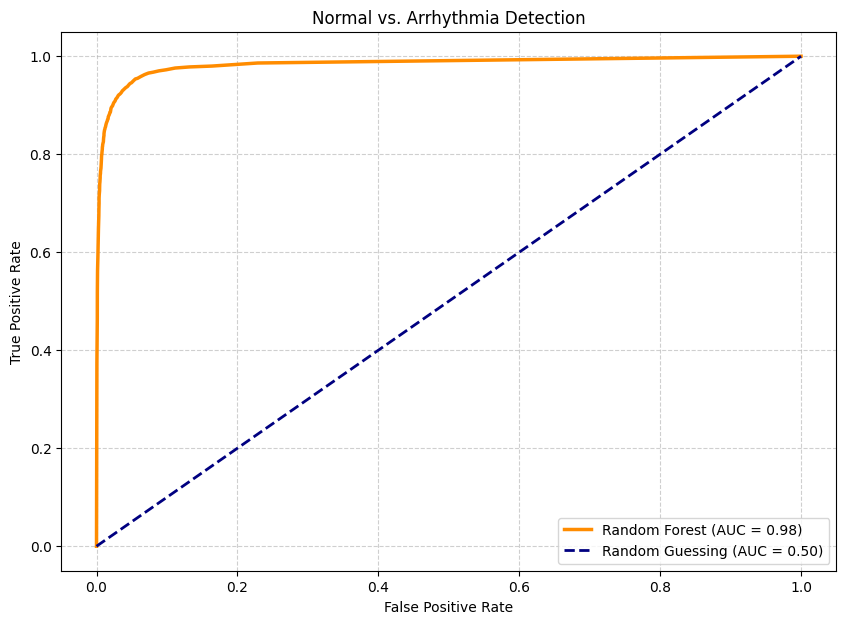

In [52]:
y_probs          = rf_binary.predict_proba(X_test)[:, 1]
fpr, tpr, _      = roc_curve(y_test, y_probs)
roc_auc          = auc(fpr, tpr)

plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Normal vs. Arrhythmia Detection')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [50]:
save_path      = f"{base_path}/"
model_filename = os.path.join(save_path, 'final_binary_ecg_model.joblib')
joblib.dump(rf_binary, model_filename)
print(f"Model saved to: {model_filename}")

Model saved to: /content/drive/My Drive/Evolutionary_ECG_Project/final_binary_ecg_model.joblib
